<a href="https://colab.research.google.com/github/rburchf1/AI102Challenges/blob/main/ryan-burchfield-ai-102-final-project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SECTION 1: PROJECT INTRODUCTION

# ORPS Categorization Assistant

## An NLP-Based Chatbot for Evaluating DOE Occurrence Reporting Criteria

**Student:** Ryan Burchfield  
**Course:** AI 102 — Natural Language Processing

## Project Overview

This project develops a retrieval-based natural language processing chatbot that assists users in evaluating whether a workplace accident or operational event may meet the Occurrence Reporting and Processing System criteria contained in DOE O 232.2A, Attachment 2.

The chatbot accepts a natural-language description of an occurrence and compares it with previously categorized occurrence records. It then recommends the most likely reporting criterion or indicates that no reporting criterion can be confidently identified.

The project applies the following NLP concepts:

- Noise reduction and text standardization
- Tokenization and lemmatization
- Part-of-speech tagging
- Dependency parsing
- Negation detection
- Semantic similarity
- TF-IDF vectorization
- Cosine similarity
- Sentence embeddings
- Topic modeling
- Context and missing-information analysis
- Confidence-based response selection

The chatbot is intended as a decision-support prototype. It does not replace review by an authorized occurrence-reporting professional.

## Section 2: Environment Setup

This section installs and imports the Python libraries required for data processing, NLP analysis, machine learning, visualization, and model evaluation.

The primary libraries used are:

- **pandas** and **NumPy** for data management
- **spaCy** for tokenization, lemmatization, part-of-speech tagging, dependency parsing, and named entity recognition
- **scikit-learn** for TF-IDF vectorization, cosine similarity, topic modeling, dataset splitting, and evaluation
- **sentence-transformers** for semantic sentence embeddings
- **Matplotlib** for charts and evaluation figures

In [18]:
# Install the additional libraries required by the notebook.

!pip install -q spacy
!pip install -q sentence-transformers
!pip install -q openpyxl

# Download the small English spaCy language model.
!python -m spacy download en_core_web_sm -q



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 45.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [19]:
import spacy
spacy.load('en_core_web_sm')

In [20]:
# Import Python libraries
from pathlib import Path
import re
import string
import warnings

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Natural language processing
import spacy

# Machine-learning utilities
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    CountVectorizer
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import NMF

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Google Drive connection
from google.colab import drive

# Suppress unnecessary warning messages
warnings.filterwarnings("ignore")

# Configure pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 300)

print("Python libraries imported successfully.")

Python libraries imported successfully.


In [5]:
# Load spaCy's English language model.
# This model provides tokenization, lemmatization,
# part-of-speech tagging, named entity recognition,
# and dependency parsing.

nlp = spacy.load("en_core_web_sm")

print("spaCy English model loaded successfully.")
print(f"Pipeline components: {nlp.pipe_names}")

spaCy English model loaded successfully.
Pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Section 3: Google Drive Connection and Project Paths

The project files are stored in Google Drive so the notebook can access the dataset, save processed data, retain trained models, and export evaluation results across multiple Colab sessions.

The project uses separate folders for:

- Raw source data
- Processed data
- Saved models
- Figures
- Evaluation results
- Chatbot examples
- Report materials

The raw source data will not be modified. All cleaned or transformed files will be saved in the processed-data folder.

In [6]:
# Connect the Colab notebook to Google Drive.

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Define the main project directory.

PROJECT_DIR = Path(
    "/content/drive/MyDrive/AI102_ORPS_Chatbot"
)

# Data folders
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"

# Notebook folder
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"

# Model folder
MODEL_DIR = PROJECT_DIR / "models"

# Output folders
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
EVALUATION_DIR = OUTPUT_DIR / "evaluation"
CHATBOT_EXAMPLES_DIR = OUTPUT_DIR / "chatbot_examples"
LOG_DIR = OUTPUT_DIR / "logs"

# Report folders
REPORT_DIR = PROJECT_DIR / "report"
REPORT_FIGURE_DIR = REPORT_DIR / "figures"

# Create folders if any are missing.
project_folders = [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    NOTEBOOK_DIR,
    MODEL_DIR,
    FIGURE_DIR,
    EVALUATION_DIR,
    CHATBOT_EXAMPLES_DIR,
    LOG_DIR,
    REPORT_DIR,
    REPORT_FIGURE_DIR
]

for folder in project_folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders verified successfully.")

Project folders verified successfully.


In [8]:
# Display the directories used by the notebook.

folder_paths = {
    "Project directory": PROJECT_DIR,
    "Raw data": RAW_DATA_DIR,
    "Processed data": PROCESSED_DATA_DIR,
    "Models": MODEL_DIR,
    "Figures": FIGURE_DIR,
    "Evaluation results": EVALUATION_DIR,
    "Chatbot examples": CHATBOT_EXAMPLES_DIR,
    "Report": REPORT_DIR
}

for folder_name, folder_path in folder_paths.items():
    print(f"{folder_name}:")
    print(f"  {folder_path}")

Project directory:
  /content/drive/MyDrive/AI102_ORPS_Chatbot
Raw data:
  /content/drive/MyDrive/AI102_ORPS_Chatbot/data/raw
Processed data:
  /content/drive/MyDrive/AI102_ORPS_Chatbot/data/processed
Models:
  /content/drive/MyDrive/AI102_ORPS_Chatbot/models
Figures:
  /content/drive/MyDrive/AI102_ORPS_Chatbot/outputs/figures
Evaluation results:
  /content/drive/MyDrive/AI102_ORPS_Chatbot/outputs/evaluation
Chatbot examples:
  /content/drive/MyDrive/AI102_ORPS_Chatbot/outputs/chatbot_examples
Report:
  /content/drive/MyDrive/AI102_ORPS_Chatbot/report


In [9]:
# Define the input and output dataset locations.

EVENT_DATA_PATH = RAW_DATA_DIR / "event_data.csv"
CLEAN_DATA_PATH = PROCESSED_DATA_DIR / "event_data_cleaned.csv"

# These files may be added later.
BLIND_TEST_PATH = RAW_DATA_DIR / "blind_test_set.csv"
DOE_CRITERIA_PATH = RAW_DATA_DIR / "doe_criteria.csv"

print("Main event dataset:")
print(EVENT_DATA_PATH)

print("\nFile exists:")
print(EVENT_DATA_PATH.exists())

Main event dataset:
/content/drive/MyDrive/AI102_ORPS_Chatbot/data/raw/event_data.csv

File exists:
True


In [10]:
# Confirm that the source dataset exists before loading it.

if not EVENT_DATA_PATH.exists():
    raise FileNotFoundError(
        "event_data.csv was not found at the expected location:\n"
        f"{EVENT_DATA_PATH}\n\n"
        "Verify the Google Drive folder name and file location."
    )

# Load the source CSV file.
event_df = pd.read_csv(EVENT_DATA_PATH)

print("Dataset loaded successfully.")
print(f"Number of rows: {event_df.shape[0]:,}")
print(f"Number of columns: {event_df.shape[1]}")

display(event_df.head())

Dataset loaded successfully.
Number of rows: 6,734
Number of columns: 2


,Event Description,Categorization
0,"On January 2, 2018, the Environment, Safety, Health and Quality Office received results of initial personal and area cadmium (Cd) exposure monitoring for an activity that was performed on December 13, 2017. The activity, performed under a Safe Work Permit (SWP), involved cleaning out the Vapor T...","2A(7) - Personnel exposure to chemical, biological or physical hazards above limits established in 10 CFR Part 851, Worker Safety and Health Program (see 10 CFR Section 851.23, Safety and Health Standards), but below levels deemed IDLH."
1,"On January 16, 2018, an employee unplugged the power cord of their laptop power supply from the recessed 120 Volt electrical receptacle located in the center of the conference room table. The employee held onto the plug with their left hand as they pulled the plug out of the receptacle, and as t...","2D(1) - Any unexpected or unintended personal contact (e.g., burn, shock, injury, etc.) with a hazardous energy source (e.g., live electrical power circuit, mechanical hazards, steam, pressurized gas, etc.)."
2,"On January 15, 2018, two researches (Researcher #1 and #2) were reconnecting radio frequency (RF) cables in the chasse under the Combi 5 Physical Vapor Deposition (PVD) tool in Lab C112 of NREL's Solar Energy Research Facility (SERF) after completing routine maintenance on the system's nitrogen ...","2D(2) - Any failure to follow a prescribed hazardous energy control process that results in potential worker exposure to uncontrolled hazardous energy (e.g., live electrical power circuit, powered mechanical hazards, steam, pressurized gas, etc.); OR any discovery of an uncontrolled hazardous en..."
3,"Event Sequence and Event Discovery: On Tuesday, April 24, 2018, at approximately 6:30 PM, a post-doctoral researcher (Researcher #1) in the Thin Film Electrochemical Laboratory (Lab E129 in the Solar Energy Research Facility, or SERF) initiated the automated catalyst regeneration sequence on an ...","4B(4) - A facility operational event which resulted in an adverse effect on safety, such as, but not limited to: (a) an inadvertent facility or operations shutdown (i.e., a change of operational mode or curtailment of work or processes); (b) a manual facility or operations shutdown due to alarm ..."
4,"On July 11, 2018, at approximately 9:00 AM, a subcontract worker (Worker #1) was observed standing on the southeast roof extension of the Science and Technology Facility (S&TF) without utilizing appropriate fall protection. Consequently, the worker was exposed to a fall hazard of approximately 1...","10(2) - A near miss to an injury, where something physically happened that was unexpected or unintended AND where no barrier prevented an event from having a reportable consequence (i.e., happenstance was the main reason the event did not result in a reportable injury)."


In [11]:
print("Original column names:")

for column in event_df.columns:
    print(f"- {column}")

print("\nDataset information:")
event_df.info()

Original column names:
- Event Description
- Categorization

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6734 entries, 0 to 6733
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Event Description  6730 non-null   object
 1   Categorization     6734 non-null   object
dtypes: object(2)
memory usage: 105.3+ KB


In [12]:
dataset_summary = pd.DataFrame({
    "Measure": [
        "Number of records",
        "Number of columns",
        "Missing values",
        "Completely duplicated rows"
    ],
    "Value": [
        len(event_df),
        len(event_df.columns),
        int(event_df.isna().sum().sum()),
        int(event_df.duplicated().sum())
    ]
})

display(dataset_summary)

,Measure,Value
0,Number of records,6734
1,Number of columns,2
2,Missing values,4
3,Completely duplicated rows,12


In [13]:
print("Setup verification")
print("-" * 40)

print(f"Google Drive mounted: {PROJECT_DIR.exists()}")
print(f"event_data.csv located: {EVENT_DATA_PATH.exists()}")
print(f"Dataset loaded: {len(event_df) > 0}")
print(f"spaCy loaded: {nlp is not None}")

print("\nDataset columns:")
print(event_df.columns.tolist())

Setup verification
----------------------------------------
Google Drive mounted: True
event_data.csv located: True
Dataset loaded: True
spaCy loaded: True

Dataset columns:
['Event Description', 'Categorization']


## Section 4: Dataset Validation and Cleaning

This section validates the event dataset and prepares it for NLP analysis.

The cleaning process includes:

- Standardizing column names
- Identifying the occurrence-description and categorization columns
- Removing rows with missing or blank values
- Standardizing non-reportable labels
- Identifying exact duplicates
- Identifying descriptions assigned to multiple criteria
- Preserving the original text before preprocessing
- Saving a cleaned working dataset

The original raw dataset is not modified.

In [15]:
# Create a working copy so the raw DataFrame remains unchanged.

df = event_df.copy()

print("Working copy created.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Working copy created.
Rows: 6,734
Columns: 2


In [23]:
description_blank = (
    df["event_description"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

categorization_blank = (
    df["categorization"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

missing_summary = pd.DataFrame({
    "Field": [
        "event_description",
        "categorization"
    ],
    "Missing_or_blank_records": [
        int(description_blank.sum()),
        int(categorization_blank.sum())
    ]
})

display(missing_summary)

,Field,Missing_or_blank_records
0,event_description,4
1,categorization,0


In [24]:
# Remove unusable records

rows_before_removal = len(df)

df = df.loc[
    ~description_blank & ~categorization_blank
].copy()

rows_removed = rows_before_removal - len(df)

print(f"Rows before removal: {rows_before_removal:,}")
print(f"Rows removed: {rows_removed:,}")
print(f"Rows remaining: {len(df):,}")

Rows before removal: 6,734
Rows removed: 4
Rows remaining: 6,730


In [25]:
# Convert both fields to strings and remove unnecessary outer whitespace.

df["event_description"] = (
    df["event_description"]
    .astype(str)
    .str.strip()
)

df["categorization"] = (
    df["categorization"]
    .astype(str)
    .str.strip()
)

print("Text fields converted to strings and trimmed.")

Text fields converted to strings and trimmed.


In [30]:
# Some historical occurrences contain more than one applicable reporting criterion. To keep the project manageable and consistent with the course scope, this prototype treats categorization as a single-label classification task. For records containing multiple criteria, the first-listed criterion is treated as the primary target label. The complete original categorization value is preserved for traceability. A future production version should use multi-label classification so that more than one applicable criterion can be predicted.

def extract_primary_category(category_value):
    """
    Return the first listed categorization code.

    This project uses a simplified single-label approach.
    The original combined categorization is preserved separately.
    """
    category_value = str(category_value).strip().upper()

    non_reportable_variations = {
        "NON REPORTABLE",
        "NON-REPORTABLE",
        "NONREPORTABLE",
        "NOT REPORTABLE",
        "NO CRITERIA MET",
        "NO CRITERION MET",
        "NO ORPS CRITERIA MET",
        "NONE"
    }

    if category_value in non_reportable_variations:
        return "NON_REPORTABLE"

    # Split on common separators and retain the first label.
    category_parts = re.split(r"[,;|\n]+", category_value)

    primary_category = category_parts[0].strip()

    return primary_category


# Preserve the complete original categorization value.
df["categorization_original"] = df["categorization"]

# Use only the first-listed criterion as the target label.
df["categorization"] = (
    df["categorization_original"]
    .apply(extract_primary_category)
)

In [29]:
# Review categorization labels

category_counts = (
    df["categorization"]
    .value_counts()
    .rename_axis("categorization")
    .reset_index(name="record_count")
)

category_counts["percentage"] = (
    category_counts["record_count"] / len(df) * 100
).round(2)

print(f"Unique category labels: {df['categorization'].nunique()}")

display(category_counts)

Unique category labels: 84


,categorization,record_count,percentage
0,2D(2) - ANY FAILURE TO FOLLOW A PRESCRIBED HAZARDOUS ENERGY CONTROL PROCESS THAT RESULTS IN POTENTIAL WORKER EXPOSURE TO UNCONTROLLED HAZARDOUS ENERGY (E.G.,1202,17.86
1,4A(1) - PERFORMANCE DEGRADATION OF ANY SAFETY CLASS (SC) OR SAFETY SIGNIFICANT (SS) STRUCTURE,1124,16.70
2,2A(5) - ANY SINGLE OCCURRENCE RESULTING IN AN OCCUPATIONAL INJURY OR EXPOSURE THAT: (A) REQUIRES IN PATIENT HOSPITALIZATION FOR MORE THAN 48 HOURS,947,14.07
3,10(2) - A NEAR MISS TO AN INJURY,519,7.71
4,3B(2) - DETERMINATION OF A POSITIVE UNREVIEWED SAFETY QUESTION (USQ) THAT REVEALS A CURRENTLY EXISTING INADEQUACY IN THE DOCUMENTED SAFETY ANALYSIS.,409,6.08
...,...,...,...
79,2B(3) - ANY FIRE IN A NUCLEAR FACILITY. 3B(2) - DETERMINATION OF A POSITIVE UNREVIEWED SAFETY QUESTION (USQ) THAT REVEALS A CURRENTLY EXISTING INADEQUACY IN THE DOCUMENTED SAFETY ANALYSIS.,1,0.01
80,2A(1) - ANY OCCURRENCE DUE TO DOE OPERATIONS RESULTING IN A FATALITY OR TERMINAL INJURY/ILLNESS. 2A(3) - ANY SINGLE OCCURRENCE,1,0.01
81,3C(2) - A CONDITION IN WHICH NO DOCUMENTED CONTROLS ARE AVAILABLE TO PREVENT A CRITICALITY ACCIDENT. AN ACCIDENT HAS NOT OCCURRED DUE TO OTHER,1,0.01
82,2C(1) - ANY UNPLANNED EXPLOSION THAT DISRUPTS NORMAL OPERATIONS. 10(2) - A NEAR MISS TO AN INJURY,1,0.01


## Section 5: Exploratory Data Analysis

Before applying natural language processing techniques, it is important to understand the characteristics of the dataset.

This exploratory analysis examines:

- Number of reportable and non-reportable events
- Distribution of reporting criteria
- Event description lengths
- Vocabulary characteristics
- Most common words
- Most common bigrams

Understanding these characteristics helps determine appropriate preprocessing and feature extraction methods.

In [33]:
is_non_reportable = df['categorization'] == 'NON_REPORTABLE'
reportability_data = {
    'Reportability': ['Reportable', 'Non-Reportable'],
    'Record Count': [
        (~is_non_reportable).sum(),
        is_non_reportable.sum()
    ]
}
reportability_counts = pd.DataFrame(reportability_data)

print("=" * 60)
print("ORPS DATASET SUMMARY")
print("=" * 60)

print(f"Total Events: {len(df):,}")
print(f"Unique Categories: {df['categorization'].nunique()}")

print("\nReportability")

display(reportability_counts)

print("\nTop Categories")

display(category_counts.head(15))

ORPS DATASET SUMMARY
Total Events: 6,730
Unique Categories: 84

Reportability


,Reportability,Record Count
0,Reportable,6470
1,Non-Reportable,260



Top Categories


,categorization,record_count,percentage
0,2D(2) - ANY FAILURE TO FOLLOW A PRESCRIBED HAZARDOUS ENERGY CONTROL PROCESS THAT RESULTS IN POTENTIAL WORKER EXPOSURE TO UNCONTROLLED HAZARDOUS ENERGY (E.G.,1202,17.86
1,4A(1) - PERFORMANCE DEGRADATION OF ANY SAFETY CLASS (SC) OR SAFETY SIGNIFICANT (SS) STRUCTURE,1124,16.70
2,2A(5) - ANY SINGLE OCCURRENCE RESULTING IN AN OCCUPATIONAL INJURY OR EXPOSURE THAT: (A) REQUIRES IN PATIENT HOSPITALIZATION FOR MORE THAN 48 HOURS,947,14.07
3,10(2) - A NEAR MISS TO AN INJURY,519,7.71
4,3B(2) - DETERMINATION OF A POSITIVE UNREVIEWED SAFETY QUESTION (USQ) THAT REVEALS A CURRENTLY EXISTING INADEQUACY IN THE DOCUMENTED SAFETY ANALYSIS.,409,6.08
5,2D(1) - ANY UNEXPECTED OR UNINTENDED PERSONAL CONTACT (E.G.,268,3.98
6,NON_REPORTABLE,260,3.86
7,3A(1) - ANY VIOLATION OR NONCOMPLIANCE OF A TECHNICAL SAFETY REQUIREMENT (OR OPERATIONAL SAFETY REQUIREMENT) SAFETY LIMIT,227,3.37
8,4A(2) - PERFORMANCE DEGRADATION OF ANY SC SSC WHEN NOT REQUIRED TO BE OPERABLE.,164,2.44
9,9(1) - ANY WRITTEN NOTIFICATION FROM AN OUTSIDE REGULATORY AGENCY THAT A SITE/FACILITY IS CONSIDERED TO BE IN NONCOMPLIANCE WITH A SCHEDULE OR REQUIREMENT.,143,2.12


In [35]:
# Number of characters

df["character_count"] = df["event_description"].str.len()

# Number of words

df["word_count"] = (
    df["event_description"]
    .str.split()
    .str.len()
)

summary = df[
    [
        "character_count",
        "word_count"
    ]
].describe()

display(summary)

,character_count,word_count
count,6730.000000,6730.000000
mean,1534.541308,242.004012
std,1696.912917,265.984252
min,25.000000,3.000000
25%,590.000000,93.000000
50%,996.500000,157.000000
75%,1794.000000,281.750000
max,30507.000000,4578.000000


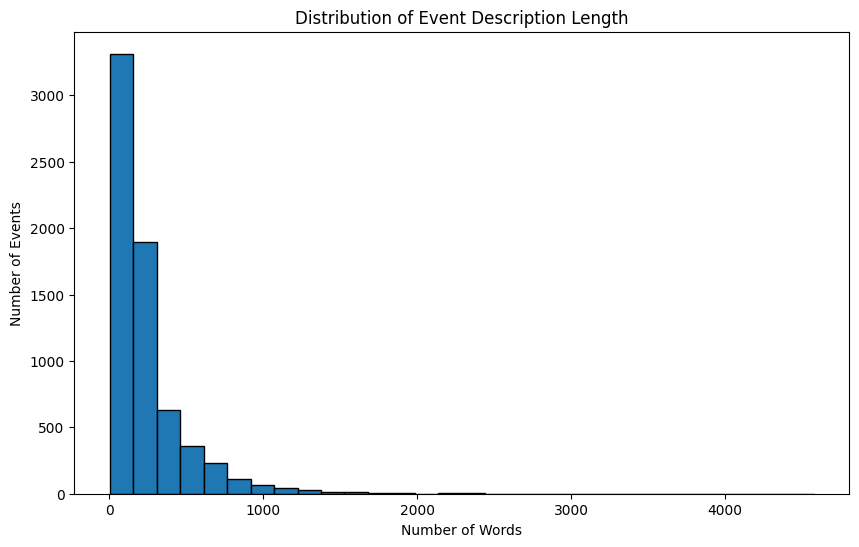

In [36]:
plt.figure(figsize=(10,6))

plt.hist(
    df["word_count"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Event Description Length")

plt.xlabel("Number of Words")

plt.ylabel("Number of Events")

plt.show()

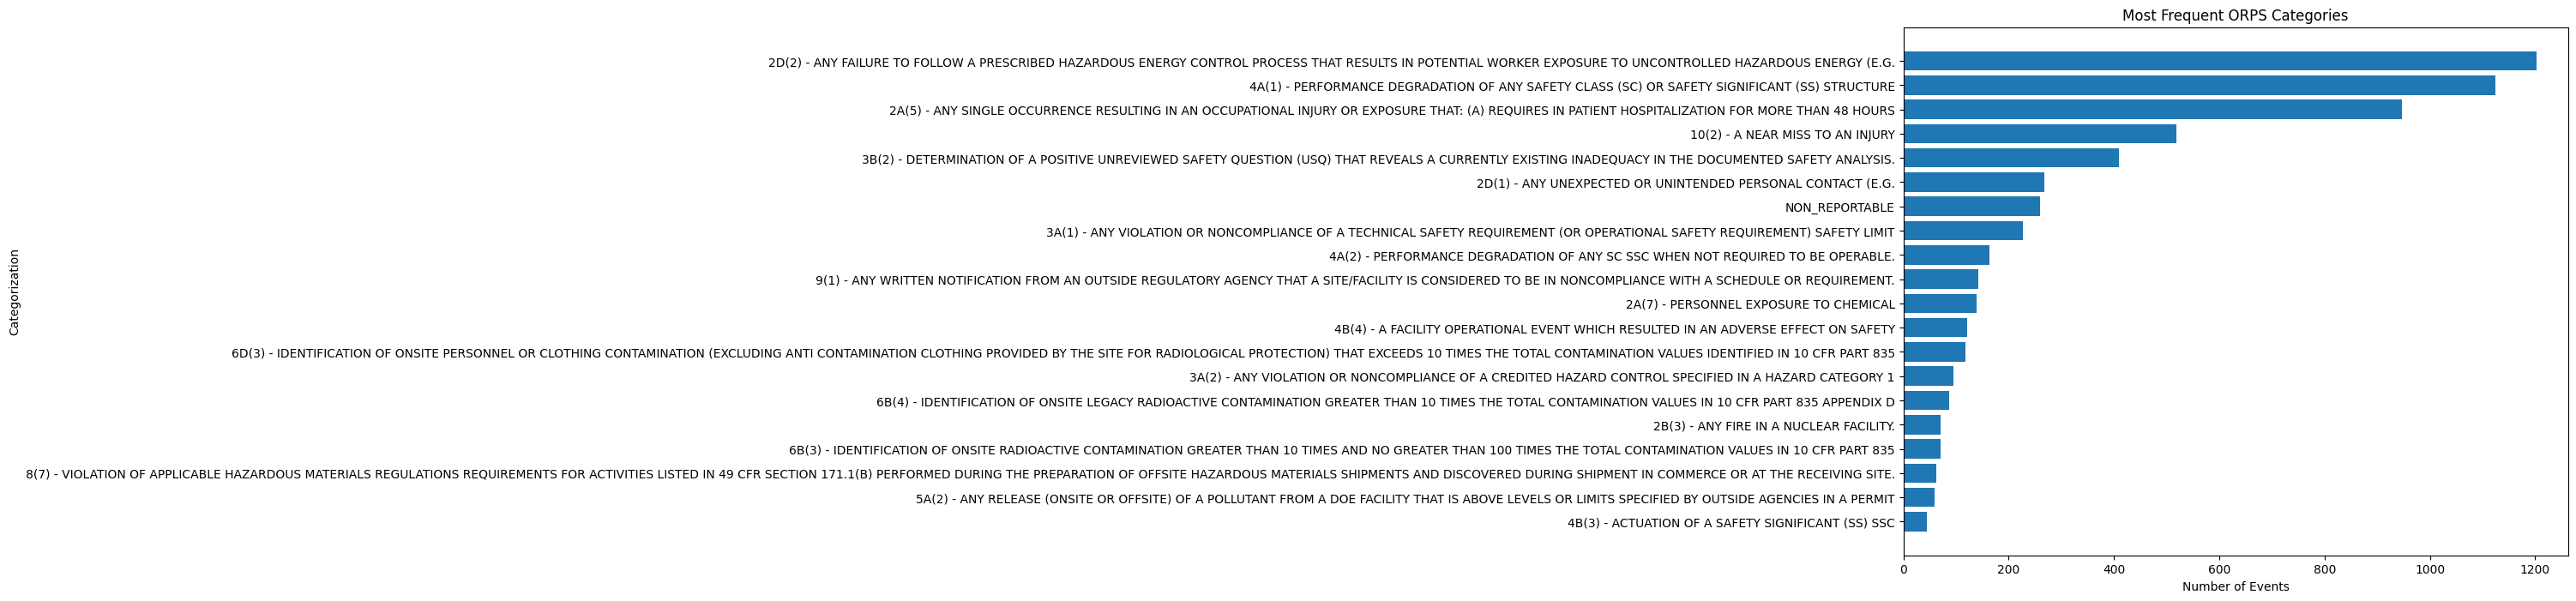

In [37]:
top20 = category_counts.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["categorization"],
    top20["record_count"]
)

plt.xlabel("Number of Events")

plt.ylabel("Categorization")

plt.title("Most Frequent ORPS Categories")

plt.gca().invert_yaxis()

plt.show()

In [40]:
vocabulary = set()

for description in df["event_description"]:

    words = description.split()

    for word in words:

        vocabulary.add(word.lower())

print(f"Vocabulary Size: {len(vocabulary):,}")

Vocabulary Size: 71,420


In [41]:
average_lengths = (
    df.groupby("categorization")["word_count"]
    .mean()
    .sort_values(ascending=False)
)

display(average_lengths.head(15))

,word_count
categorization,
6C(1) - DETERMINATION OF A DOSE THAT EXCEEDS THE LIMITS SPECIFIED IN 10 CFR PART 835,2301.000000
3B(2) - DETERMINATION OF A POSITIVE UNREVIEWED SAFETY QUESTION (USQ) THAT REVEALS A CURRENTLY EXISTING INADEQUACY IN THE DOCUMENTED SAFETY ANALYSIS. 3C(3) - A LOSS OF ONE OR MORE NUCLEAR CRITICALITY DOCUMENTED CONTROLS SUCH THAT AN ACCIDENTAL CRITICALITY IS POSSIBLE FROM THE LOSS OF ONE ADDITIONAL DOCUMENTED CONTROL.,1120.000000
3B(2) - DETERMINATION OF A POSITIVE UNREVIEWED SAFETY QUESTION (USQ) THAT REVEALS A CURRENTLY EXISTING INADEQUACY IN THE DOCUMENTED SAFETY ANALYSIS. 10(1) - AN EVENT,1103.333333
9(1) - ANY WRITTEN NOTIFICATION FROM AN OUTSIDE REGULATORY AGENCY THAT A SITE/FACILITY IS CONSIDERED TO BE IN NONCOMPLIANCE WITH A SCHEDULE OR REQUIREMENT. 10(1) - AN EVENT,1094.000000
2C(1) - ANY UNPLANNED EXPLOSION THAT DISRUPTS NORMAL OPERATIONS. 4B(4) - A FACILITY OPERATIONAL EVENT WHICH RESULTED IN AN ADVERSE EFFECT ON SAFETY,1056.000000
2C(1) - ANY UNPLANNED EXPLOSION THAT DISRUPTS NORMAL OPERATIONS. 3B(2) - DETERMINATION OF A POSITIVE UNREVIEWED SAFETY QUESTION (USQ) THAT REVEALS A CURRENTLY EXISTING INADEQUACY IN THE DOCUMENTED SAFETY ANALYSIS.,986.000000
6D(2) - IDENTIFICATION OF OFFSITE PERSONNEL OR CLOTHING CONTAMINATION DUE TO DOE OPERATIONS/ACTIVITIES THAT EXCEEDS 1 TIMES THE TOTAL CONTAMINATION VALUES IN 10 CFR PART 835,903.000000
6C(3) - DETERMINATION OF A SINGLE OCCUPATIONAL DOSE,784.000000
6B(1) - IDENTIFICATION OF OFFSITE RADIOACTIVE CONTAMINATION DUE TO DOE OPERATIONS/ACTIVITIES THAT EXCEEDS APPLICABLE DOE APPROVED AUTHORIZED LIMITS (PURSUANT TO DOE O 458.1 CHG 3,631.800000


In [43]:
from collections import Counter

counter = Counter()

for description in df["event_description"]:

    counter.update(description.lower().split())

common_words = pd.DataFrame(
    counter.most_common(30),
    columns=["Word","Frequency"]
)

display(common_words)

,Word,Frequency
0,the,142936
1,and,45239
2,to,42420
3,a,36455
4,of,34829
5,was,31860
6,on,23557
7,in,23014
8,at,16801
9,for,13458


In [45]:
from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english",
    max_features=25
)

X = bigram_vectorizer.fit_transform(
    df["event_description"]
)

bigram_counts = (
    pd.DataFrame(
        {
            "Bigram": bigram_vectorizer.get_feature_names_out(),
            "Count": X.sum(axis=0).A1
        }
    )
    .sort_values(
        "Count",
        ascending=False
    )
)

display(bigram_counts)

,Bigram,Count
23,ta 55,1547
22,safety analysis,1043
8,hazardous energy,1034
7,fact finding,973
20,report level,795
1,categorized event,786
2,date time,774
5,facility operations,731
17,operations manager,700
16,operations center,673


In [46]:
histogram_path = FIGURE_DIR / "description_length_distribution.png"

category_path = FIGURE_DIR / "category_distribution.png"

# Histogram

plt.figure(figsize=(10,6))

plt.hist(
    df["word_count"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Event Description Length")

plt.xlabel("Words")

plt.ylabel("Events")

plt.savefig(
    histogram_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# Category chart

plt.figure(figsize=(10,8))

plt.barh(
    top20["categorization"],
    top20["record_count"]
)

plt.gca().invert_yaxis()

plt.xlabel("Events")

plt.title("Most Frequent ORPS Categories")

plt.savefig(
    category_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Figures saved.")

Figures saved.


In [47]:
eda_summary = pd.DataFrame({

    "Metric":[
        "Total Events",
        "Unique Categories",
        "Vocabulary Size",
        "Average Words/Event",
        "Longest Description",
        "Shortest Description"
    ],

    "Value":[
        len(df),
        df["categorization"].nunique(),
        len(vocabulary),
        round(df["word_count"].mean(),1),
        df["word_count"].max(),
        df["word_count"].min()
    ]

})

display(eda_summary)

,Metric,Value
0,Total Events,6730.0
1,Unique Categories,84.0
2,Vocabulary Size,71420.0
3,Average Words/Event,242.0
4,Longest Description,4578.0
5,Shortest Description,3.0


## Section 6: Text Processing, Noise Reduction, and Standardization

Raw occurrence descriptions may contain inconsistent capitalization, extra whitespace, punctuation differences, abbreviations, formatting artifacts, and other sources of textual noise.

This section creates a reusable text-processing pipeline that:

- Converts text to a consistent format
- Removes unnecessary formatting artifacts
- Normalizes whitespace
- Standardizes selected abbreviations
- Preserves numbers, measurements, and negation terms
- Creates a cleaned text field for later NLP analysis

Important safety-related information such as voltage, quantities, temperatures, pressure, and negative statements is retained because these details may affect categorization.

In [48]:
# Common abbreviations and variations found in occurrence descriptions.
# This dictionary can be expanded later if additional patterns are found.

ABBREVIATION_MAP = {
    r"\bemp\b": "employee",
    r"\bempl\b": "employee",
    r"\bmed eval\b": "medical evaluation",
    r"\bmed evaluation\b": "medical evaluation",
    r"\bhosp\b": "hospital",
    r"\binj\b": "injury",
    r"\binjuries\b": "injuries",
    r"\brecv'd\b": "received",
    r"\brecd\b": "received",
    r"\bequip\b": "equipment",
    r"\bmaint\b": "maintenance",
    r"\btemp\b": "temperature",
    r"\bapprox\b": "approximately",
    r"\bdept\b": "department",
    r"\bvac\b": "vac",
    r"\bac\b": "alternating current",
    r"\bdc\b": "direct current"
}

print(f"Number of abbreviation rules: {len(ABBREVIATION_MAP)}")

Number of abbreviation rules: 17


In [49]:
def clean_text(text):
    """
    Clean and standardize an occurrence description.

    Processing steps:
    1. Convert the value to a string.
    2. Convert text to lowercase.
    3. Remove HTML tags.
    4. Normalize quotation marks and dashes.
    5. Replace selected abbreviations.
    6. Preserve letters, numbers, decimal points, percent signs,
       hyphens, parentheses, and selected measurement symbols.
    7. Normalize repeated whitespace.

    Parameters
    ----------
    text : str
        Raw occurrence description.

    Returns
    -------
    str
        Cleaned occurrence description.
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # Convert to lowercase for consistent comparison.
    text = text.lower()

    # Remove HTML tags.
    text = re.sub(r"<[^>]+>", " ", text)

    # Normalize common Unicode quotation marks.
    text = text.replace("“", '"')
    text = text.replace("”", '"')
    text = text.replace("’", "'")
    text = text.replace("‘", "'")

    # Normalize long dashes.
    text = text.replace("–", "-")
    text = text.replace("—", "-")

    # Apply abbreviation replacements.
    for pattern, replacement in ABBREVIATION_MAP.items():
        text = re.sub(pattern, replacement, text)

    # Replace selected punctuation with spaces.
    text = re.sub(r"[,:;!?]", " ", text)

    # Preserve useful technical characters.
    # Retained characters include:
    # letters, numbers, spaces, periods, percent signs,
    # parentheses, slashes, apostrophes, plus signs,
    # minus signs, and degree symbols.
    text = re.sub(
        r"[^a-z0-9\s\.\%\(\)\/'\+\-\°]",
        " ",
        text
    )

    # Normalize repeated periods.
    text = re.sub(r"\.{2,}", ".", text)

    # Normalize repeated whitespace.
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [50]:
sample_texts = [
    "EMP recv'd a 110-V AC shock while opening the controller.",
    "No injury occurred; the employee received a precautionary med eval.",
    "Approximately 2.5 gallons spilled at 70°C -- no release off-site.",
    "<p>The EQUIP was de-energized before maintenance.</p>"
]

for index, sample in enumerate(sample_texts, start=1):
    print(f"Example {index}")
    print("Original:")
    print(sample)

    print("\nCleaned:")
    print(clean_text(sample))

    print("-" * 70)

Example 1
Original:
EMP recv'd a 110-V AC shock while opening the controller.

Cleaned:
employee received a 110-v alternating current shock while opening the controller.
----------------------------------------------------------------------
Example 2
Original:
No injury occurred; the employee received a precautionary med eval.

Cleaned:
no injury occurred the employee received a precautionary medical evaluation.
----------------------------------------------------------------------
Example 3
Original:
Approximately 2.5 gallons spilled at 70°C -- no release off-site.

Cleaned:
approximately 2.5 gallons spilled at 70°c -- no release off-site.
----------------------------------------------------------------------
Example 4
Original:
<p>The EQUIP was de-energized before maintenance.</p>

Cleaned:
the equipment was de-energized before maintenance.
----------------------------------------------------------------------


In [56]:
# Create a new column rather than overwriting the original description.

df["cleaned_description"] = (
    df["event_description"]
    .apply(clean_text)
)

print("Text cleaning completed.")
display(
    df[
        [
            "event_description",
            "cleaned_description"
        ]
    ].head(10)
)

Text cleaning completed.


,event_description,cleaned_description
0,"On January 2, 2018, the Environment, Safety, Health and Quality Office received results of initial personal and area cadmium (Cd) exposure monitoring for an activity that was performed on December 13, 2017. The activity, performed under a Safe Work Permit (SWP), involved cleaning out the Vapor T...",on january 2 2018 the environment safety health and quality office received results of initial personal and area cadmium (cd) exposure monitoring for an activity that was performed on december 13 2017. the activity performed under a safe work permit (swp) involved cleaning out the vapor transpor...
1,"On January 16, 2018, an employee unplugged the power cord of their laptop power supply from the recessed 120 Volt electrical receptacle located in the center of the conference room table. The employee held onto the plug with their left hand as they pulled the plug out of the receptacle, and as t...",on january 16 2018 an employee unplugged the power cord of their laptop power supply from the recessed 120 volt electrical receptacle located in the center of the conference room table. the employee held onto the plug with their left hand as they pulled the plug out of the receptacle and as they...
2,"On January 15, 2018, two researches (Researcher #1 and #2) were reconnecting radio frequency (RF) cables in the chasse under the Combi 5 Physical Vapor Deposition (PVD) tool in Lab C112 of NREL's Solar Energy Research Facility (SERF) after completing routine maintenance on the system's nitrogen ...",on january 15 2018 two researches (researcher 1 and 2) were reconnecting radio frequency (rf) cables in the chasse under the combi 5 physical vapor deposition (pvd) tool in lab c112 of nrel's solar energy research facility (serf) after completing routine maintenance on the system's nitrogen crac...
3,"Event Sequence and Event Discovery: On Tuesday, April 24, 2018, at approximately 6:30 PM, a post-doctoral researcher (Researcher #1) in the Thin Film Electrochemical Laboratory (Lab E129 in the Solar Energy Research Facility, or SERF) initiated the automated catalyst regeneration sequence on an ...",event sequence and event discovery on tuesday april 24 2018 at approximately 6 30 pm a post-doctoral researcher (researcher 1) in the thin film electrochemical laboratory (lab e129 in the solar energy research facility or serf) initiated the automated catalyst regeneration sequence on an mbraun ...
4,"On July 11, 2018, at approximately 9:00 AM, a subcontract worker (Worker #1) was observed standing on the southeast roof extension of the Science and Technology Facility (S&TF) without utilizing appropriate fall protection. Consequently, the worker was exposed to a fall hazard of approximately 1...",on july 11 2018 at approximately 9 00 am a subcontract worker (worker 1) was observed standing on the southeast roof extension of the science and technology facility (s tf) without utilizing appropriate fall protection. consequently the worker was exposed to a fall hazard of approximately 13-15 ...
5,"On the morning of Friday, August 17, 2018, Energy Systems Integration Facility (ESIF) Operations, ESIF Engineering, and Environment, Safety, and Health (ESH) personnel were preparing to perform a confined space entry in the electrical vault in the fenced area north of Lab C339 of the ESIF. Powe...",on the morning of friday august 17 2018 energy systems integration facility (esif) operations esif engineering and environment safety and health (esh) personnel were preparing to perform a confined space entry in the electrical vault in the fenced area north of lab c339 of the esif. power to the...
6,"On Monday, October 1, 2018, an NREL Qualified Electrical Worker 3 (QEW 3) discovered a cord containing four conductors with ring style wire end blade connectors (3-480V phase conductors and a ground) hanging free. The cord was located in a remote, low-traffic area on the third floor mezzanine le...",on monday october 1 2018 an nrel q

In [57]:
empty_cleaned_mask = (
    df["cleaned_description"]
    .fillna("")
    .str.strip()
    .eq("")
)

empty_cleaned_count = int(empty_cleaned_mask.sum())

print(
    "Records with an empty cleaned description: "
    f"{empty_cleaned_count}"
)

if empty_cleaned_count > 0:
    display(
        df.loc[
            empty_cleaned_mask,
            [
                "event_description",
                "cleaned_description"
            ]
        ].head(20)
    )

Records with an empty cleaned description: 0


In [58]:
df["original_character_count"] = (
    df["event_description"]
    .astype(str)
    .str.len()
)

df["cleaned_character_count"] = (
    df["cleaned_description"]
    .str.len()
)

df["original_word_count"] = (
    df["event_description"]
    .astype(str)
    .str.split()
    .str.len()
)

df["cleaned_word_count"] = (
    df["cleaned_description"]
    .str.split()
    .str.len()
)

length_comparison = pd.DataFrame({
    "Measure": [
        "Average original characters",
        "Average cleaned characters",
        "Average original words",
        "Average cleaned words"
    ],
    "Value": [
        round(df["original_character_count"].mean(), 2),
        round(df["cleaned_character_count"].mean(), 2),
        round(df["original_word_count"].mean(), 2),
        round(df["cleaned_word_count"].mean(), 2)
    ]
})

display(length_comparison)

,Measure,Value
0,Average original characters,1534.54
1,Average cleaned characters,1518.73
2,Average original words,242.00
3,Average cleaned words,242.48


In [59]:
NEGATION_TERMS = {
    "no",
    "not",
    "never",
    "none",
    "without",
    "neither",
    "nor",
    "didn't",
    "wasn't",
    "weren't",
    "isn't",
    "aren't",
    "hadn't",
    "hasn't",
    "haven't",
    "couldn't",
    "wouldn't",
    "shouldn't"
}


def find_negation_terms(text):
    """
    Return the negation terms found in a text description.
    """
    tokens = re.findall(r"\b[\w']+\b", str(text).lower())

    return [
        token
        for token in tokens
        if token in NEGATION_TERMS
    ]


df["negation_terms"] = (
    df["cleaned_description"]
    .apply(find_negation_terms)
)

df["contains_negation"] = (
    df["negation_terms"]
    .apply(lambda terms: len(terms) > 0)
)

negation_summary = pd.DataFrame({
    "Measure": [
        "Descriptions containing negation",
        "Descriptions without negation"
    ],
    "Count": [
        int(df["contains_negation"].sum()),
        int((~df["contains_negation"]).sum())
    ]
})

display(negation_summary)

,Measure,Count
0,Descriptions containing negation,4737
1,Descriptions without negation,1993


In [60]:
negation_examples = df.loc[
    df["contains_negation"],
    [
        "cleaned_description",
        "negation_terms",
        "categorization"
    ]
].head(15)

display(negation_examples)

,cleaned_description,negation_terms,categorization
0,on january 2 2018 the environment safety health and quality office received results of initial personal and area cadmium (cd) exposure monitoring for an activity that was performed on december 13 2017. the activity performed under a safe work permit (swp) involved cleaning out the vapor transpor...,"[not, no, without, not, not, not, no, not, not, not]",2A(7) - PERSONNEL EXPOSURE TO CHEMICAL
1,on january 16 2018 an employee unplugged the power cord of their laptop power supply from the recessed 120 volt electrical receptacle located in the center of the conference room table. the employee held onto the plug with their left hand as they pulled the plug out of the receptacle and as they...,"[not, no]",2D(1) - ANY UNEXPECTED OR UNINTENDED PERSONAL CONTACT (E.G.
2,on january 15 2018 two researches (researcher 1 and 2) were reconnecting radio frequency (rf) cables in the chasse under the combi 5 physical vapor deposition (pvd) tool in lab c112 of nrel's solar energy research facility (serf) after completing routine maintenance on the system's nitrogen crac...,"[no, no, not, not, not, no, no, without]",2D(2) - ANY FAILURE TO FOLLOW A PRESCRIBED HAZARDOUS ENERGY CONTROL PROCESS THAT RESULTS IN POTENTIAL WORKER EXPOSURE TO UNCONTROLLED HAZARDOUS ENERGY (E.G.
3,event sequence and event discovery on tuesday april 24 2018 at approximately 6 30 pm a post-doctoral researcher (researcher 1) in the thin film electrochemical laboratory (lab e129 in the solar energy research facility or serf) initiated the automated catalyst regeneration sequence on an mbraun ...,"[not, without, no, not, no, no, no, not, not, not, not, not, not, not, not, nor, not, no, not, not, not, not, not, not, not, no, not, not, none, not]",4B(4) - A FACILITY OPERATIONAL EVENT WHICH RESULTED IN AN ADVERSE EFFECT ON SAFETY
4,on july 11 2018 at approximately 9 00 am a subcontract worker (worker 1) was observed standing on the southeast roof extension of the science and technology facility (s tf) without utilizing appropriate fall protection. consequently the worker was exposed to a fall hazard of approximately 13-15 ...,"[without, not, not, without, no, not]",10(2) - A NEAR MISS TO AN INJURY
5,on the morning of friday august 17 2018 energy systems integration facility (esif) operations esif engineering and environment safety and health (esh) personnel were preparing to perform a confined space entry in the electrical vault in the fenced area north of lab c339 of the esif. power to the...,"[not, no, no, no, no]",10(2) - A NEAR MISS TO AN INJURY
6,on monday october 1 2018 an nrel qualified electrical worker 3 (qew 3) discovered a cord containing four conductors with ring style wire end blade connectors (3-480v phase conductors and a ground) hanging free. the cord was located in a remote low-traffic area on the third floor mezzanine level ...,"[not, not, not, not, no, not, not, not]",2D(2) - ANY FAILURE TO FOLLOW A PRESCRIBED HAZARDOUS ENERGY CONTROL PROCESS THAT RESULTS IN POTENTIAL WORKER EXPOSURE TO UNCONTROLLED HAZARDOUS ENERGY (E.G.
7,event discovery and response on thursday october 18 2018 an nrel researcher (an undergraduate student intern) received a shock to her left hand from an exposed 120 volt (v) conductor. the worker was readying an experimental sample to run in an altamira ami-390 furnace a frequently used piece of ...,"[not, no, without, not, not, not, not, not, not, not, no, not, not, no, nor]",2D(1) - ANY UNEXPECTED OR UNINTENDED PERSONAL CONTACT (E.G.
8,on november 6 2018 the environment safety health and quality office received results of personal silica monitoring collected on october 16 2018. during the month of october nrel performed an industrial hygiene survey on construction sites located on the nrel south table mountain campus to assess...,"[not, not, not]",2A(7) - PERSONNEL EXPOSURE TO CHEMICAL
9,on the morning of january 19th an employee at the separations process research unit (spru) slipped and 

In [61]:
from spacy.lang.en.stop_words import STOP_WORDS

# Create a copy of spaCy's stop-word set.
CUSTOM_STOP_WORDS = set(STOP_WORDS)

# Preserve negation terms.
CUSTOM_STOP_WORDS = (
    CUSTOM_STOP_WORDS - NEGATION_TERMS
)

# Preserve additional operationally meaningful words.
PRESERVED_TERMS = {
    "before",
    "after",
    "above",
    "below",
    "against",
    "during",
    "through",
    "under",
    "over"
}

CUSTOM_STOP_WORDS = (
    CUSTOM_STOP_WORDS - PRESERVED_TERMS
)

print(f"spaCy stop words: {len(STOP_WORDS)}")
print(f"Custom stop words: {len(CUSTOM_STOP_WORDS)}")

print("\nNegation terms preserved:")
print(sorted(
    term
    for term in NEGATION_TERMS
    if term not in CUSTOM_STOP_WORDS
))

spaCy stop words: 326
Custom stop words: 310

Negation terms preserved:
["aren't", "couldn't", "didn't", "hadn't", "hasn't", "haven't", "isn't", 'neither', 'never', 'no', 'none', 'nor', 'not', "shouldn't", "wasn't", "weren't", 'without', "wouldn't"]


In [62]:
def extract_numeric_expressions(text):
    """
    Extract simple numbers and measurement expressions.

    Examples:
    110 vac
    2.5 gallons
    70 degrees
    480 volts
    3 employees
    """
    text = str(text).lower()

    pattern = (
        r"\b\d+(?:\.\d+)?"
        r"(?:\s*[-/]?\s*"
        r"(?:vac|volts?|kv|amps?|amperes?|"
        r"gallons?|liters?|ml|kg|lbs?|pounds?|"
        r"degrees?|°c|°f|percent|%|hours?|minutes?|"
        r"employees?|workers?))?"
        r"\b"
    )

    return re.findall(pattern, text)


df["numeric_expressions"] = (
    df["cleaned_description"]
    .apply(extract_numeric_expressions)
)

df["numeric_expression_count"] = (
    df["numeric_expressions"]
    .apply(len)
)

display(
    df[
        [
            "record_id",
            "cleaned_description",
            "numeric_expressions"
        ]
    ].head(15)
)

KeyError: "['record_id'] not in index"

In [63]:
cleaned_word_counter = Counter()

for description in df["cleaned_description"]:
    tokens = re.findall(r"\b[a-z0-9']+\b", description)
    cleaned_word_counter.update(tokens)

cleaned_common_words = pd.DataFrame(
    cleaned_word_counter.most_common(30),
    columns=["word", "frequency"]
)

display(cleaned_common_words)

,word,frequency
0,the,143106
1,and,45537
2,to,42975
3,a,37674
4,of,34954
5,was,31875
6,on,24143
7,in,23478
8,at,16845
9,for,13495


In [64]:
TEXT_PROCESSED_DATA_PATH = (
    PROCESSED_DATA_DIR /
    "event_data_text_processed.csv"
)

df.to_csv(
    TEXT_PROCESSED_DATA_PATH,
    index=False
)

print("Text-processed dataset saved successfully.")
print(TEXT_PROCESSED_DATA_PATH)
print(f"File exists: {TEXT_PROCESSED_DATA_PATH.exists()}")

Text-processed dataset saved successfully.
/content/drive/MyDrive/AI102_ORPS_Chatbot/data/processed/event_data_text_processed.csv
File exists: True


In [65]:
text_processing_summary = pd.DataFrame({
    "Metric": [
        "Total records",
        "Empty cleaned descriptions",
        "Descriptions containing negation",
        "Average original word count",
        "Average cleaned word count",
        "Descriptions containing numeric expressions"
    ],
    "Value": [
        len(df),
        empty_cleaned_count,
        int(df["contains_negation"].sum()),
        round(df["original_word_count"].mean(), 2),
        round(df["cleaned_word_count"].mean(), 2),
        int((df["numeric_expression_count"] > 0).sum())
    ]
})

TEXT_PROCESSING_SUMMARY_PATH = (
    EVALUATION_DIR /
    "text_processing_summary.csv"
)

text_processing_summary.to_csv(
    TEXT_PROCESSING_SUMMARY_PATH,
    index=False
)

display(text_processing_summary)

,Metric,Value
0,Total records,6730.00
1,Empty cleaned descriptions,0.00
2,Descriptions containing negation,4737.00
3,Average original word count,242.00
4,Average cleaned word count,242.48
5,Descriptions containing numeric expressions,6505.00


In [66]:
print("Section 6 verification")
print("-" * 50)

required_text_columns = [
    "cleaned_description",
    "negation_terms",
    "contains_negation",
    "numeric_expressions",
    "numeric_expression_count"
]

for column in required_text_columns:
    print(f"{column}: {column in df.columns}")

print(
    "\nEmpty cleaned descriptions: "
    f"{df['cleaned_description'].str.strip().eq('').sum()}"
)

print(
    "Processed file saved: "
    f"{TEXT_PROCESSED_DATA_PATH.exists()}"
)

Section 6 verification
--------------------------------------------------
cleaned_description: True
negation_terms: True
contains_negation: True
numeric_expressions: True
numeric_expression_count: True

Empty cleaned descriptions: 0
Processed file saved: True


# Section 6 - Text Processing

This section prepares the event descriptions for natural language processing.

The preprocessing pipeline performs:

- Text standardization
- Tokenization
- Lemmatization
- Stop-word removal
- Preservation of important negation words (e.g., "no", "not")

In [67]:
# Text preprocessing function

from spacy.lang.en.stop_words import STOP_WORDS

# Keep important negation words
custom_stopwords = STOP_WORDS - {
    "no",
    "not",
    "nor",
    "never",
    "none",
    "without"
}

def preprocess_text(text):

    doc = nlp(str(text).lower())

    tokens = []

    for token in doc:

        # Skip punctuation and spaces
        if token.is_punct or token.is_space:
            continue

        lemma = token.lemma_.strip()

        if lemma in custom_stopwords:
            continue

        tokens.append(lemma)

    return " ".join(tokens)

In [68]:
df["processed_text"] = df["event_description"].apply(preprocess_text)

display(
    df[
        [
            "event_description",
            "processed_text"
        ]
    ].head(10)
)

,event_description,processed_text
0,"On January 2, 2018, the Environment, Safety, Health and Quality Office received results of initial personal and area cadmium (Cd) exposure monitoring for an activity that was performed on December 13, 2017. The activity, performed under a Safe Work Permit (SWP), involved cleaning out the Vapor T...",january 2 2018 environment safety health quality office receive result initial personal area cadmium cd exposure monitoring activity perform december 13 2017 activity perform safe work permit swp involve clean vapor transport deposition vtd chamber s&tf 205 time determine level potential exposur...
1,"On January 16, 2018, an employee unplugged the power cord of their laptop power supply from the recessed 120 Volt electrical receptacle located in the center of the conference room table. The employee held onto the plug with their left hand as they pulled the plug out of the receptacle, and as t...",january 16 2018 employee unplug power cord laptop power supply recess 120 volt electrical receptacle locate center conference room table employee hold plug left hand pull plug receptacle left index finger contact expose energized prong partially receptacle employee left wrist touch metal casing ...
2,"On January 15, 2018, two researches (Researcher #1 and #2) were reconnecting radio frequency (RF) cables in the chasse under the Combi 5 Physical Vapor Deposition (PVD) tool in Lab C112 of NREL's Solar Energy Research Facility (SERF) after completing routine maintenance on the system's nitrogen ...",january 15 2018 research researcher 1 2 reconnecte radio frequency rf cable chasse combi 5 physical vapor deposition pvd tool lab c112 nrel solar energy research facility serf complete routine maintenance system nitrogen cracker researcher 2 rout rf cable equipment rack metal connector insulate ...
3,"Event Sequence and Event Discovery: On Tuesday, April 24, 2018, at approximately 6:30 PM, a post-doctoral researcher (Researcher #1) in the Thin Film Electrochemical Laboratory (Lab E129 in the Solar Energy Research Facility, or SERF) initiated the automated catalyst regeneration sequence on an ...",event sequence event discovery tuesday april 24 2018 approximately 6:30 pm post doctoral researcher researcher 1 thin film electrochemical laboratory lab e129 solar energy research facility serf initiate automate catalyst regeneration sequence mbraun unilab glovebox lab approximately minute late...
4,"On July 11, 2018, at approximately 9:00 AM, a subcontract worker (Worker #1) was observed standing on the southeast roof extension of the Science and Technology Facility (S&TF) without utilizing appropriate fall protection. Consequently, the worker was exposed to a fall hazard of approximately 1...",july 11 2018 approximately 9:00 subcontract worker worker 1 observe stand southeast roof extension science technology facility s&tf without utilize appropriate fall protection consequently worker expose fall hazard approximately 13 15 foot worker supervisor convergint security camera subcontract...
5,"On the morning of Friday, August 17, 2018, Energy Systems Integration Facility (ESIF) Operations, ESIF Engineering, and Environment, Safety, and Health (ESH) personnel were preparing to perform a confined space entry in the electrical vault in the fenced area north of Lab C339 of the ESIF. Powe...",morning friday august 17 2018 energy system integration facility esif operation esif engineering environment safety health esh personnel prepare perform confine space entry electrical vault fence area north lab c339 esif power associate 480 volt panel dsb hbp3 9 lock verify de energized worker p...
6,"On Monday, October 1, 2018, an NREL Qualified Electrical Worker 3 (QEW 3) discovered a cord containing four conductors with ring style wire end blade connectors (3-480V phase conductors and a ground) hanging free. The cord was located in a remote, low-traffic area on the third floor mezzanine le...",monday october 1 2018 nrel qualified el

In [70]:
sample = 15

print("Original\n")
print(df.loc[sample,"event_description"])

print("\nProcessed\n")
print(df.loc[sample,"processed_text"])

Original

On January 17, 2018, FBP received a letter from the Ohio EPA, Failure to Sample; LT2 - Facility lD#6657269; October 2017 and November 2017, dated January 10, 2018.  This letter contained the following violation: ln accordance with Ohio Administrative Coda (OAC) Rule 3745-S1-65(lX2) and OAC Rule 3745-81-66-(A): Surface water Public Water Supplies (PWS) are required to collect samples within two days before or two days after the dates indicated in their sampling schedule and to report source water monitoring results no later than 10 days after the end of the first month following the month when the sample is collected. 1.  The required long term 2 (LT2) samples scheduled for October 4, 2017, and October 18, 2017, were not collected within the allowed time frame which is two days prior to or two days following the actual scheduled dates. 1.  The required LT2 samples scheduled for November 1, 2017, November 15, 2017, and November 29, 2017, were not collected within the allowed ti

# Section 7 - Syntactic Analysis

Syntactic analysis examines the grammatical structure of a sentence rather than just the individual words.

This section uses spaCy to identify:

- Tokens
- Lemmas
- Part-of-Speech (POS) tags
- Dependency relationships

These features help identify who performed an action, what action occurred, and what object was involved. This information will later be used to help explain the chatbot's categorization decisions.

In [71]:
# Analyze one event using spaCy

sample = 15          # Change this number to examine another event

doc = nlp(df.loc[sample, "event_description"])

print(df.loc[sample, "event_description"])

On January 17, 2018, FBP received a letter from the Ohio EPA, Failure to Sample; LT2 - Facility lD#6657269; October 2017 and November 2017, dated January 10, 2018.  This letter contained the following violation: ln accordance with Ohio Administrative Coda (OAC) Rule 3745-S1-65(lX2) and OAC Rule 3745-81-66-(A): Surface water Public Water Supplies (PWS) are required to collect samples within two days before or two days after the dates indicated in their sampling schedule and to report source water monitoring results no later than 10 days after the end of the first month following the month when the sample is collected. 1.  The required long term 2 (LT2) samples scheduled for October 4, 2017, and October 18, 2017, were not collected within the allowed time frame which is two days prior to or two days following the actual scheduled dates. 1.  The required LT2 samples scheduled for November 1, 2017, November 15, 2017, and November 29, 2017, were not collected within the allowed time frame w

In [72]:
analysis = []

for token in doc:

    analysis.append({

        "Token": token.text,

        "Lemma": token.lemma_,

        "POS": token.pos_,

        "Dependency": token.dep_

    })

analysis_df = pd.DataFrame(analysis)

display(analysis_df)

,Token,Lemma,POS,Dependency
0,On,on,ADP,prep
1,January,January,PROPN,pobj
2,17,17,NUM,nummod
3,",",",",PUNCT,punct
4,2018,2018,NUM,nummod
...,...,...,...,...
232,Actions,Actions,PROPN,pobj
233,8024,8024,NUM,nummod
234,and,and,CCONJ,cc
235,8025,8025,NUM,conj


In [73]:
subject = None
action = None
objects = []

for token in doc:

    if token.dep_ in ("nsubj", "nsubjpass"):
        subject = token.text

    if token.dep_ == "ROOT":
        action = token.lemma_

    if token.dep_ in ("dobj", "pobj", "attr"):
        objects.append(token.text)

print("Subject :", subject)
print("Action  :", action)
print("Objects :", objects)

Subject : which
Action  : extend
Objects : ['January', 'letter', 'EPA', 'Sample', 'violation', 'Coda', 'samples', 'schedule', 'results', 'end', 'month', 'month', 'October', 'frame', 'dates', 'November', 'frame', 'dates', 'date', 'Actions']


In [97]:
def extract_named_entities(text):

    doc = nlp(text)

    entities = []

    for entity in doc.ents:

        entities.append({
            "Text": entity.text,
            "Type": entity.label_
        })

    return pd.DataFrame(entities)

In [98]:
#Test

query = """
An employee contacted an energized
120 VAC conductor on July 10, 2026.

Medical personnel evaluated the employee.
"""

extract_named_entities(query)

,Text,Type
0,120,CARDINAL
1,VAC,ORG
2,"July 10, 2026",DATE


In [75]:
def syntactic_summary(text):

    doc = nlp(text)

    subject = None
    action = None
    objects = []

    for token in doc:

        if token.dep_ in ("nsubj", "nsubjpass"):
            subject = token.text

        if token.dep_ == "ROOT":
            action = token.lemma_

        if token.dep_ in ("dobj", "pobj", "attr"):
            objects.append(token.text)

    return {

        "subject": subject,

        "action": action,

        "objects": objects

    }

In [76]:
summary = syntactic_summary(
    df.loc[sample, "event_description"]
)

summary

{'subject': 'which',
 'action': 'extend',
 'objects': ['January',
  'letter',
  'EPA',
  'Sample',
  'violation',
  'Coda',
  'samples',
  'schedule',
  'results',
  'end',
  'month',
  'month',
  'October',
  'frame',
  'dates',
  'November',
  'frame',
  'dates',
  'date',
  'Actions']}

# Section 8 - Semantic Analysis

This section converts each event description into a numerical representation using
Term Frequency-Inverse Document Frequency (TF-IDF).

TF-IDF assigns greater weight to words that are important to a particular event
while reducing the influence of very common words.

Cosine similarity is then used to compare a new event description with the
historical ORPS occurrence database to identify the most similar previously
categorized events.

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Build the TF-IDF vocabulary

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=2
)

tfidf_matrix = tfidf.fit_transform(df["processed_text"])

print(f"Number of documents : {tfidf_matrix.shape[0]}")
print(f"Vocabulary size     : {tfidf_matrix.shape[1]}")

Number of documents : 6730
Vocabulary size     : 106992


In [78]:
from sklearn.metrics.pairwise import cosine_similarity

def retrieve_similar_events(query, top_k=10):

    # Process the user's description
    processed_query = preprocess_text(query)

    # Convert to TF-IDF vector
    query_vector = tfidf.transform([processed_query])

    # Compute similarity
    similarity = cosine_similarity(
        query_vector,
        tfidf_matrix
    ).flatten()

    # Get the most similar events
    top_indices = similarity.argsort()[-top_k:][::-1]

    results = df.iloc[top_indices].copy()

    results["Similarity"] = similarity[top_indices]

    return results[
        [
            "event_description",
            "categorization",
            "Similarity"
        ]
    ]

In [79]:
query = """
Employee contacted an energized
120 VAC electrical conductor while
performing troubleshooting.
"""

retrieve_similar_events(query)

,event_description,categorization,Similarity
159,"On 01/29/2018 Hanford Fire Department (HFD) Fire Systems Maintenance (FSM) declared a stop work on all fire alarm control units (FACU), when access into the FACU is required, until an electrician has verified that there is no exposed hazardous energy greater than or equal to 50 volts per DOE 035...",2D(2) - ANY FAILURE TO FOLLOW A PRESCRIBED HAZARDOUS ENERGY CONTROL PROCESS THAT RESULTS IN POTENTIAL WORKER EXPOSURE TO UNCONTROLLED HAZARDOUS ENERGY (E.G.,0.196676
678,"On August 17, 2018, a UT-Battelle Instrumentation & Control (I&C) technician was calibrating a glovebox exhaust fan control loop as part of an annual surveillance requirement. Technicians were completing their 2nd day of a multi-module work activity. The glovebox exhaust fan control loop is 24...",2D(1) - ANY UNEXPECTED OR UNINTENDED PERSONAL CONTACT (E.G.,0.174820
5934,"On Tuesday, November 18, 2025, at approximately 12:15 p.m. (MT), a technologist in Department 8344 was troubleshooting an instrument that was not communicating with a computer. The technologist had removed the side panel and began swapping a USB cable used to connect two boards on an exposed ci...",2D(2) - ANY FAILURE TO FOLLOW A PRESCRIBED HAZARDOUS ENERGY CONTROL PROCESS THAT RESULTS IN POTENTIAL WORKER EXPOSURE TO UNCONTROLLED HAZARDOUS ENERGY (E.G.,0.138376
1351,"On August 6, 2019 an Instrument and Controls (I&C) Technician at the Hot Fuels Examination Facility (HFEF) was performing an annual preventive maintenance (PM) activity on the HFEF inter-facility pneumatic transfer system and discovered 120 VAC. Part of the PM required entry into an electrical j...",2D(2) - ANY FAILURE TO FOLLOW A PRESCRIBED HAZARDOUS ENERGY CONTROL PROCESS THAT RESULTS IN POTENTIAL WORKER EXPOSURE TO UNCONTROLLED HAZARDOUS ENERGY (E.G.,0.137262
6371,"On January 14, 2026, at approximately 11:10 a.m. (MT), a worker from B&D Electric, a second-tier subcontractor, contacted an energized 120 V wire while performing electrical work on the cooling tower motor located at Building 858N. The wires for the heater were within the motor, but the motor he...",2D(1) - ANY UNEXPECTED OR UNINTENDED PERSONAL CONTACT (E.G.,0.133080


In [80]:
query = """
Employee received a fractured finger
while moving heavy equipment.
"""

retrieve_similar_events(query)

,event_description,categorization,Similarity
2926,"On 09/08/2022 at 1700 hours, the TA-54 Facility Operations Director was notified that an individual was experiencing heat stress symptoms while supporting the CMP Retrieval Operations. On 09/08/2022, CMP Retrieval Operations commenced with a planned evolution to uncover a single CMP and obtain n...",10(2) - A NEAR MISS TO AN INJURY,0.274142
4983,"At 1100 on 5/28/2024 an Infrastructure and Operations, Heavy Equipment Group employee was performing maintenance on an exhaust fan on the roof of B451 and reportedly used their hand to slow down the belt of the fan which had residual mechanical energy (winding down after shutdown) after being el...",2D(1) - ANY UNEXPECTED OR UNINTENDED PERSONAL CONTACT (E.G.,0.169077
5560,"On May 15, 2025, a Heavy Equipment Oiler (Oiler) noticed that there was oil in the bed/walkway of the truck. The oil spill was the result of residual discharge from the truck's transfer pump. The Oiler used absorbent materials in an attempt to clean up the oil spill but did not succeed in comple...",2A(5) - ANY SINGLE OCCURRENCE RESULTING IN AN OCCUPATIONAL INJURY OR EXPOSURE THAT: (A) REQUIRES IN PATIENT HOSPITALIZATION FOR MORE THAN 48 HOURS,0.166101
773,"MANAGEMENT SYNOPSIS: On January 9, 2019 at 1533 hours, the CH-TRU Shift Operations Manager (SOM) notified the CH-TRU TA54 Facility Operations Manager (OM) of an equipment operator performing snow removal without a spotter present. N3B had requested and received approval of a variance to the req...",3A(2) - ANY VIOLATION OR NONCOMPLIANCE OF A CREDITED HAZARD CONTROL SPECIFIED IN A HAZARD CATEGORY 1,0.148632
5806,"On 06/12/25, at 1228 pm, an employee was performing troubleshooting activities on a breaker rack locked on the south side of the pumphouse building. Employee identified a tripped breaker that was the source of the issue. When the employee attempted to open the access point for safe touch verific...",2D(1) - ANY UNEXPECTED OR UNINTENDED PERSONAL CONTACT (E.G.,0.126571


In [124]:
def predict_category(query, top_k=10):

    results = retrieve_similar_events(query, top_k)

    prediction = (
        results["categorization"]
        .mode()
        .iloc[0]
    )

    confidence = results["Similarity"].mean()

    return {

        "Predicted Category": prediction,

        "Confidence": round(confidence,3),

        "Supporting Events": len(results),

        "Retrieved Events": results

    }

In [87]:
query = """
Employee contacted energized electrical
equipment and experienced tingling in one hand.
"""

prediction = predict_category(query)

prediction

{'Predicted Category': '2D(1) - ANY UNEXPECTED OR UNINTENDED PERSONAL CONTACT (E.G.',
 'Confidence': np.float64(0.11),
 'Supporting Events': 10}

In [88]:
query = """
While repairing an electrical cabinet,
an employee accidentally contacted an
energized conductor and experienced
an electrical shock.
"""

predict_category(query)

{'Predicted Category': '2D(1) - ANY UNEXPECTED OR UNINTENDED PERSONAL CONTACT (E.G.',
 'Confidence': np.float64(0.152),
 'Supporting Events': 10}

# Section 9 - Explainable AI

One limitation of retrieval-based chatbots is that they often provide a recommendation without explaining the reasoning.

To improve transparency, this chatbot extracts important evidence from the user's event description. The extracted evidence is presented alongside the predicted ORPS categorization to help the user understand why the recommendation was made.

This evidence extraction is rule-based and complements the statistical similarity model.

In [89]:
import re

EVIDENCE_PATTERNS = {

    "Electrical": [
        r"\belectric",
        r"\benergized",
        r"\bvoltage",
        r"\bvac\b",
        r"\bkv\b",
        r"\bshock\b",
        r"\bcurrent\b",
        r"\bconductor\b"
    ],

    "Chemical": [
        r"\bchemical",
        r"\bacid\b",
        r"\bsolvent\b",
        r"\bnitric\b",
        r"\bspill\b",
        r"\brelease\b"
    ],

    "Fire": [
        r"\bfire\b",
        r"\bsmoke\b",
        r"\bburn\b",
        r"\bflame\b",
        r"\bexplosion\b"
    ],

    "Injury": [
        r"\binjury\b",
        r"\bfracture\b",
        r"\bburn\b",
        r"\bshock\b",
        r"\bhospital\b",
        r"\bmedical\b",
        r"\btingling\b"
    ]
}

In [90]:
def extract_evidence(text):

    text = text.lower()

    evidence = {}

    for category, patterns in EVIDENCE_PATTERNS.items():

        found = []

        for pattern in patterns:

            if re.search(pattern, text):

                found.append(pattern.replace(r"\b",""))

        evidence[category] = found

    return evidence

In [91]:
# Test

query = """
Employee contacted an energized
120 VAC conductor while troubleshooting.
Employee experienced tingling in the hand.
"""

extract_evidence(query)

{'Electrical': ['energized', 'vac', 'conductor'],
 'Chemical': [],
 'Fire': [],
 'Injury': ['tingling']}

In [92]:
def summarize_evidence(text):

    evidence = extract_evidence(text)

    summary = []

    for category, words in evidence.items():

        if len(words) > 0:

            summary.append(

                f"{category}: {', '.join(words)}"

            )

    return summary

In [93]:
summarize_evidence(query)

['Electrical: energized, vac, conductor', 'Injury: tingling']

In [99]:
def analyze_event(query):

    prediction = predict_category(query)

    evidence = summarize_evidence(query)

    entities = extract_named_entities(query)

    print("=" * 60)

    print("Predicted ORPS Category")
    print(prediction["Predicted Category"])

    print(f"\nConfidence: {prediction['Confidence']:.2f}")

    print("\nEvidence Identified")

    if evidence:
        for item in evidence:
            print(f"• {item}")
    else:
        print("• No rule-based evidence detected.")

    if not entities.empty:

        print("\nNamed Entities")

        for _, row in entities.iterrows():
            print(f"• {row['Text']} ({row['Type']})")

    print("=" * 60)

In [106]:
def analyze_event(query):

    prediction = predict_category(query)

    evidence = summarize_evidence(query)

    entities = extract_named_entities(query)

    # Generate explanation using Gemini
    gemini_explanation = get_gemini_explanation(query, prediction, evidence, entities)

    print("=" * 60)

    print("Predicted ORPS Category")
    print(prediction["Predicted Category"])

    print(f"\nConfidence: {prediction['Confidence']:.2f}")

    print("\nEvidence Identified")

    if evidence:
        for item in evidence:
            print(f"• {item}")
    else:
        print("• No rule-based evidence detected.")

    if not entities.empty:

        print("\nNamed Entities")

        for _, row in entities.iterrows():
            print(f"• {row['Text']} ({row['Type']})")

    print("\nGemini Explanation:")
    print(gemini_explanation)

    print("=" * 60)

### Test the updated `analyze_event` function with Gemini Explanation

In [107]:
query = """
An employee contacted an energized
120 VAC electrical conductor while
troubleshooting equipment.

The employee experienced tingling in
one finger and was evaluated by medical
personnel on July 10, 2026.
"""

analyze_event(query)

DefaultCredentialsError: 
  No API_KEY or ADC found. Please either:
    - Set the `GOOGLE_API_KEY` environment variable.
    - Manually pass the key with `genai.configure(api_key=my_api_key)`.
    - Or set up Application Default Credentials, see https://ai.google.dev/gemini-api/docs/oauth for more information.

In [100]:
query = """
An employee contacted an energized
120 VAC electrical conductor while
troubleshooting equipment.

The employee experienced tingling in
one finger and was evaluated by medical
personnel on July 10, 2026.
"""

analyze_event(query)

Predicted ORPS Category
2A(5) - ANY SINGLE OCCURRENCE RESULTING IN AN OCCUPATIONAL INJURY OR EXPOSURE THAT: (A) REQUIRES IN PATIENT HOSPITALIZATION FOR MORE THAN 48 HOURS

Confidence: 0.11

Evidence Identified
• Electrical: electric, energized, vac, conductor
• Injury: medical, tingling

Named Entities
• 120 (CARDINAL)
• VAC (ORG)
• one (CARDINAL)
• July 10, 2026 (DATE)


In [95]:
query = """
An employee contacted an energized
120 VAC electrical conductor while
troubleshooting equipment.

The employee experienced tingling in
one finger and was evaluated by medical
personnel.
"""

analyze_event(query)

Predicted ORPS Category
2D(2) - ANY FAILURE TO FOLLOW A PRESCRIBED HAZARDOUS ENERGY CONTROL PROCESS THAT RESULTS IN POTENTIAL WORKER EXPOSURE TO UNCONTROLLED HAZARDOUS ENERGY (E.G.

Confidence: 0.12

Evidence Identified
• Electrical: electric, energized, vac, conductor
• Injury: medical, tingling


# Section 10 - Grounded LLM Explanations and Human Feedback

The retrieval model determines the recommended ORPS category using TF-IDF and cosine similarity.

A small generative transformer model is used only to:

- Summarize supporting evidence
- Explain similarities to historical events
- Identify missing information
- Produce a clear recommendation for the user

The chatbot also collects user feedback. Confirmed or corrected categorizations are saved for controlled future retraining. The model does not automatically retrain after every interaction.

In [112]:
# Import the Python SDK
import google.generativeai as genai
# Used to securely store your API key
from google.colab import userdata
userdata.get('GOOGLE_API_KEY')

GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')

genai.configure(api_key=GOOGLE_API_KEY)

In [113]:
# Initialize the Gemini API
gemini_model = genai.GenerativeModel('gemini-2.5-flash')

In [116]:
def get_gemini_explanation(query, prediction, evidence, entities):
    """
    Generates an explanation for the predicted ORPS category using Gemini.
    """
    prompt = f"""You are an expert in workplace safety and occurrence reporting.
    An event description has been provided: '{query}'

    Based on our analysis, the predicted ORPS category is '{prediction['Predicted Category']}' with a confidence of {prediction['Confidence']:.2f}.

    Rule-based evidence found in the description includes:
    {'; '.join(evidence) if evidence else 'No specific rule-based evidence.'}

    Named entities identified in the description are:
    {'; '.join([f'{e.Text} ({e.Type})' for _, e in entities.iterrows()]) if not entities.empty else 'No named entities.'}

    PWrite a concise preliminary ORPS categorization explanation.
    Use only the information provided below.
    Do not invent facts.
    Do not state that the recommendation is final.
    Explain which facts support the recommendation.
    Identify important missing information when appropriate.
    Limit the answer to approximately 120 words.
    """

    response = gemini_model.generate_content(prompt)
    return response.text

In [117]:
query = """
An employee contacted an energized
120 VAC electrical conductor while
troubleshooting equipment.

The employee experienced tingling in
one finger and was evaluated by medical
personnel.
"""

analyze_event(query)

Predicted ORPS Category
2D(2) - ANY FAILURE TO FOLLOW A PRESCRIBED HAZARDOUS ENERGY CONTROL PROCESS THAT RESULTS IN POTENTIAL WORKER EXPOSURE TO UNCONTROLLED HAZARDOUS ENERGY (E.G.

Confidence: 0.12

Evidence Identified
• Electrical: electric, energized, vac, conductor
• Injury: medical, tingling

Named Entities
• 120 (CARDINAL)
• VAC (ORG)
• one (CARDINAL)

Gemini Explanation:
This preliminary ORPS categorization recommends '2D(2) - ANY FAILURE TO FOLLOW A PRESCRIBED HAZARDOUS ENERGY CONTROL PROCESS THAT RESULTS IN POTENTIAL WORKER EXPOSURE TO UNCONTROLLED HAZARDOUS ENERGY'.

The event description supports this by detailing an employee contacting an "energized 120 VAC electrical conductor" while "troubleshooting equipment," which directly indicates exposure to uncontrolled hazardous energy. Rule-based evidence such as "energized," "electrical," "VAC," and "conductor" confirms the hazardous energy component. The employee experienced "tingling" and required "medical" evaluation, signify

In [118]:
LOW_CONFIDENCE_THRESHOLD = 0.20

MISSING_DETAIL_PATTERNS = {
    "injury or medical outcome": [
        r"\binjur",
        r"\bmedical",
        r"\bhospital",
        r"\bfirst aid",
        r"\bfracture",
        r"\bburn",
        r"\bshock"
    ],
    "quantity or measurement": [
        r"\b\d+(\.\d+)?\b",
        r"\bgallon",
        r"\bliter",
        r"\bvolt",
        r"\bvac\b",
        r"\bpercent",
        r"\bkg\b",
        r"\blb\b"
    ],
    "release or exposure outcome": [
        r"\brelease",
        r"\bspill",
        r"\bexposure",
        r"\bcontact",
        r"\bcontamination"
    ]
}


def identify_missing_information(text):
    """
    Identify broad information types not detected in the description.
    """

    text = text.lower()
    missing = []

    for detail, patterns in MISSING_DETAIL_PATTERNS.items():
        found = any(re.search(pattern, text) for pattern in patterns)

        if not found:
            missing.append(detail)

    return missing

In [122]:
def chatbot_analysis(query, use_llm=True, top_k=5):
    """
    Run retrieval, evidence extraction, missing-information
    analysis, and optional LLM explanation.
    """

    prediction = predict_category(query, top_k=top_k)
    evidence = summarize_evidence(query)
    missing_information = identify_missing_information(query)

    confidence = prediction["Confidence"]

    if confidence < LOW_CONFIDENCE_THRESHOLD:
        recommendation = (
            "Insufficient similarity to make a confident "
            "categorization recommendation."
        )
    else:
        recommendation = prediction["Predicted Category"]

    explanation = None

    if use_llm:
        explanation = get_gemini_explanation(
            query=query,
            prediction=prediction,
            evidence=evidence,
            entities=extract_named_entities(query)
        )

    return {
        "recommendation": recommendation,
        "predicted_category": prediction["Predicted Category"],
        "confidence": confidence,
        "evidence": evidence,
        "missing_information": missing_information,
        "explanation": explanation,
        "similar_events": prediction["Retrieved Events"]
    }

In [126]:
def display_chatbot_response(result):
    print("=" * 70)
    print("ORPS CATEGORIZATION ASSISTANT")
    print("=" * 70)

    print("\nPreliminary recommendation:")
    print(result["recommendation"])

    print(f"\nSimilarity confidence: {result['confidence']:.2f}")

    print("\nSupporting evidence:")
    if result["evidence"]:
        for item in result["evidence"]:
            print(f"- {item}")
    else:
        print("- No predefined evidence patterns detected.")

    if result["missing_information"]:
        print("\nPotentially missing information:")
        for item in result["missing_information"]:
            print(f"- {item}")

    if result["explanation"]:
        print("\nGenerated explanation:")
        print(result["explanation"])

    print("\nMost similar historical events:")
    display(
        result["similar_events"][
            ["categorization", "Similarity", "event_description"]
        ].head(3)
    )

    print(
        "\nThis is a preliminary decision-support recommendation "
        "and requires qualified human review."
    )

In [127]:
query = """
An employee contacted an energized 120 VAC conductor while
troubleshooting a motor controller. The employee experienced
tingling in one finger and was evaluated by medical personnel.
"""

result = chatbot_analysis(
    query,
    use_llm=True
)

display_chatbot_response(result)

ORPS CATEGORIZATION ASSISTANT

Preliminary recommendation:
Insufficient similarity to make a confident categorization recommendation.

Similarity confidence: 0.17

Supporting evidence:
- Electrical: energized, vac, conductor
- Injury: medical, tingling

Generated explanation:
The preliminary ORPS categorization is 2D(2) - ANY FAILURE TO FOLLOW A PRESCRIBED HAZARDOUS ENERGY CONTROL PROCESS THAT RESULTS IN POTENTIAL WORKER EXPOSURE TO UNCONTROLLED HAZARDOUS ENERGY. This is supported by the employee contacting an "energized 120 VAC conductor" while "troubleshooting a motor controller," indicating exposure to "uncontrolled hazardous energy." The resulting "tingling in one finger" and "medical personnel" evaluation confirm an actual exposure and potential injury.

Important missing information includes whether a prescribed hazardous energy control process was in place, and the specific nature of any "failure to follow" it. The description details the outcome of contact with hazardous energy

,categorization,Similarity,event_description
6450,2D(2) - ANY FAILURE TO FOLLOW A PRESCRIBED HAZARDOUS ENERGY CONTROL PROCESS THAT RESULTS IN POTENTIAL WORKER EXPOSURE TO UNCONTROLLED HAZARDOUS ENERGY (E.G.,0.251794,"On June 8, 2026, a UT-Battelle, LLC (UT-Battelle) employee received a 34-volt alternating current (VAC) electrical shock while attempting to set up a spare motor controller for a needle grinder in Building 3025M. The employee opened the primary motor controller to use it as a reference for confi..."
118,2D(2) - ANY FAILURE TO FOLLOW A PRESCRIBED HAZARDOUS ENERGY CONTROL PROCESS THAT RESULTS IN POTENTIAL WORKER EXPOSURE TO UNCONTROLLED HAZARDOUS ENERGY (E.G.,0.161306,"On 12/17/18, the Oak Ridge National Laboratory (ORNL) Waste Disposition Operations (WDO) project and ORNL Operations and Cleanup Enterprise (OOCE) maintenance personnel commenced with a lock out / tag out (LOTO) to replace the motor actuator and controller for an overhead door at building 7574. ..."
159,2D(2) - ANY FAILURE TO FOLLOW A PRESCRIBED HAZARDOUS ENERGY CONTROL PROCESS THAT RESULTS IN POTENTIAL WORKER EXPOSURE TO UNCONTROLLED HAZARDOUS ENERGY (E.G.,0.142860,"On 01/29/2018 Hanford Fire Department (HFD) Fire Systems Maintenance (FSM) declared a stop work on all fire alarm control units (FACU), when access into the FACU is required, until an electrician has verified that there is no exposed hazardous energy greater than or equal to 50 volts per DOE 035..."



This is a preliminary decision-support recommendation and requires qualified human review.


# SECTION 11 - Human-in-the-Loop Learning

This section provides code to continue to train the chatbot to improve responses.



In [128]:
from datetime import datetime

FEEDBACK_PATH = (
    PROCESSED_DATA_DIR /
    "chatbot_feedback.csv"
)

In [129]:
def save_feedback(
    description,
    predicted_category,
    feedback_status,
    corrected_category=""
):
    """
    Save confirmed, corrected, or uncertain feedback.

    feedback_status must be:
    - confirmed
    - corrected
    - unsure
    """

    valid_statuses = {
        "confirmed",
        "corrected",
        "unsure"
    }

    if feedback_status not in valid_statuses:
        raise ValueError(
            f"Feedback status must be one of {valid_statuses}."
        )

    record = pd.DataFrame([{
        "description": description,
        "predicted_category": predicted_category,
        "feedback_status": feedback_status,
        "corrected_category": corrected_category,
        "timestamp": datetime.now().isoformat()
    }])

    write_header = not FEEDBACK_PATH.exists()

    record.to_csv(
        FEEDBACK_PATH,
        mode="a",
        header=write_header,
        index=False
    )

    print("Feedback saved.")

In [130]:
def retrain_with_approved_feedback():
    """
    Rebuild the retrieval model using confirmed and corrected
    feedback records.

    Unsure records are excluded.
    """

    global df, tfidf, tfidf_matrix

    if not FEEDBACK_PATH.exists():
        print("No feedback file was found.")
        return

    feedback_df = pd.read_csv(FEEDBACK_PATH)

    approved = feedback_df[
        feedback_df["feedback_status"].isin(
            ["confirmed", "corrected"]
        )
    ].copy()

    if approved.empty:
        print("No approved feedback is available.")
        return

    approved["categorization"] = np.where(
        approved["feedback_status"] == "confirmed",
        approved["predicted_category"],
        approved["corrected_category"]
    )

    approved = approved[
        approved["categorization"]
        .fillna("")
        .str.strip()
        .ne("")
    ].copy()

    approved["processed_text"] = (
        approved["description"]
        .apply(preprocess_text)
    )

    feedback_training_data = approved[
        [
            "description",
            "categorization",
            "processed_text"
        ]
    ]

    base_training_data = df[
        [
            "description",
            "categorization",
            "processed_text"
        ]
    ]

    df = (
        pd.concat(
            [base_training_data, feedback_training_data],
            ignore_index=True
        )
        .drop_duplicates(
            subset=["description", "categorization"]
        )
        .reset_index(drop=True)
    )

    tfidf_matrix = tfidf.fit_transform(
        df["processed_text"]
    )

    print(
        f"Retrieval model rebuilt using {len(df):,} records."
    )